In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
%matplotlib inline

In [7]:
df = pd.read_csv("../data/AB_NYC_2019.csv")
print("Shape:", df.shape)
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [9]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [10]:
df.describe(include="object")

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


In [11]:
df.isnull().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
id                                    0
host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
print("Zero prices:", (df["price"] == 0).sum())
print("Negative prices:", (df["price"] < 0).sum())
print("Price > 1000:", (df["price"] > 1000).sum())
print("Price > 500:", (df["price"] > 500).sum())
print("\nPrice percentiles:")
print(df["price"].quantile([0.5, 0.9, 0.95, 0.99, 0.995, 0.999]))

Zero prices: 11
Negative prices: 0
Price > 1000: 239
Price > 500: 1044

Price percentiles:
0.500     106.0
0.900     269.0
0.950     355.0
0.990     799.0
0.995    1000.0
0.999    3000.0
Name: price, dtype: float64


In [13]:
for col in ["neighbourhood_group", "neighbourhood", "room_type"]:
    print(f"{col}: {df[col].nunique()} unique values")
print("\nTop 10 neighbourhoods:")
print(df["neighbourhood"].value_counts().head(10))

neighbourhood_group: 5 unique values
neighbourhood: 221 unique values
room_type: 3 unique values

Top 10 neighbourhoods:
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


In [14]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate ids:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate ids: 0


In [15]:
mask = df["last_review"].isnull()
print("Rows with missing last_review:", mask.sum())
print("All of them have 0 reviews:", (df.loc[mask, "number_of_reviews"] == 0).all())
print("Any non-null last_review with NaN reviews_per_month:",
      df.loc[~mask, "reviews_per_month"].isnull().sum())

Rows with missing last_review: 10052
All of them have 0 reviews: True
Any non-null last_review with NaN reviews_per_month: 0


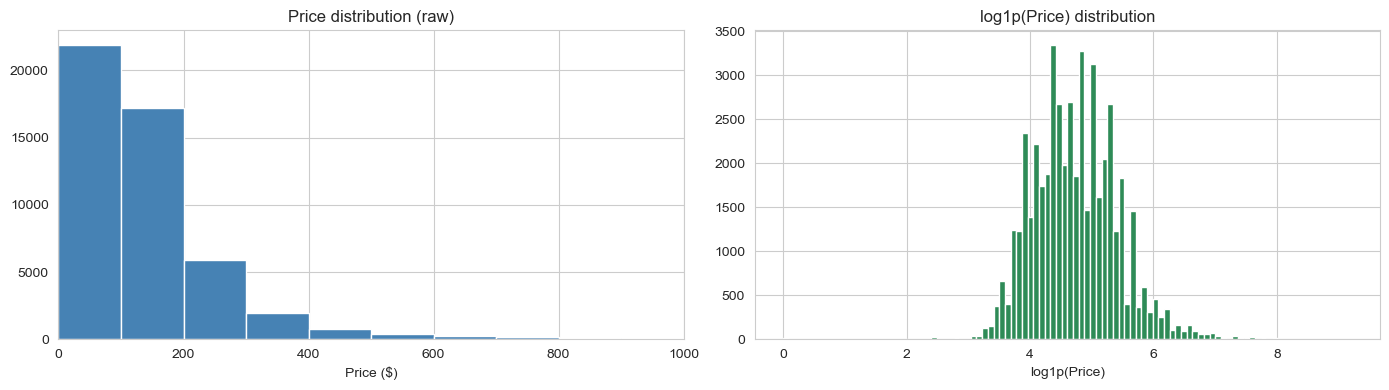

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["price"].hist(bins=100, ax=axes[0], color="steelblue")
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price ($)")
axes[0].set_xlim(0, 1000)

np.log1p(df["price"]).hist(bins=100, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(Price) distribution")
axes[1].set_xlabel("log1p(Price)")

plt.tight_layout()
plt.show()

In [17]:
df_clean = df.copy()

# Drop identifier + free-text columns
drop_cols = ["id", "host_id", "host_name", "name", "last_review"]
df_clean = df_clean.drop(columns=drop_cols)

# Drop rows with price == 0 (invalid listings)
before = len(df_clean)
df_clean = df_clean[df_clean["price"] > 0].reset_index(drop=True)
after = len(df_clean)

print(f"Dropped {before - after} rows with price == 0")
print("New shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Dropped 11 rows with price == 0
New shape: (48884, 11)

Remaining columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [18]:
# Missing reviews_per_month means "no reviews yet" -> fill with 0
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

print("Missing values after fill:")
print(df_clean.isnull().sum())

Missing values after fill:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [19]:
# Cap price at 99th percentile (keeps the row, limits influence of extreme values)
price_cap = df_clean["price"].quantile(0.99)
print(f"Price 99th percentile: ${price_cap:.0f}")

# Cap minimum_nights at 99th percentile (max is 1250 nights!)
nights_cap = df_clean["minimum_nights"].quantile(0.99)
print(f"minimum_nights 99th percentile: {nights_cap:.0f}")

# Cap calculated_host_listings_count at 99th percentile
host_cap = df_clean["calculated_host_listings_count"].quantile(0.99)
print(f"calculated_host_listings_count 99th percentile: {host_cap:.0f}")

df_clean["price"] = df_clean["price"].clip(upper=price_cap)
df_clean["minimum_nights"] = df_clean["minimum_nights"].clip(upper=nights_cap)
df_clean["calculated_host_listings_count"] = df_clean["calculated_host_listings_count"].clip(upper=host_cap)

print("\nAfter clipping:")
print(df_clean[["price", "minimum_nights", "calculated_host_listings_count"]].describe())

Price 99th percentile: $799
minimum_nights 99th percentile: 45
calculated_host_listings_count 99th percentile: 232

After clipping:
              price  minimum_nights  calculated_host_listings_count
count  48884.000000    48884.000000                    48884.000000
mean     143.988626        6.116480                        6.509144
std      121.929660        9.244575                       27.194563
min       10.000000        1.000000                        1.000000
25%       69.000000        1.000000                        1.000000
50%      106.000000        3.000000                        1.000000
75%      175.000000        5.000000                        2.000000
max      799.000000       45.000000                      232.000000


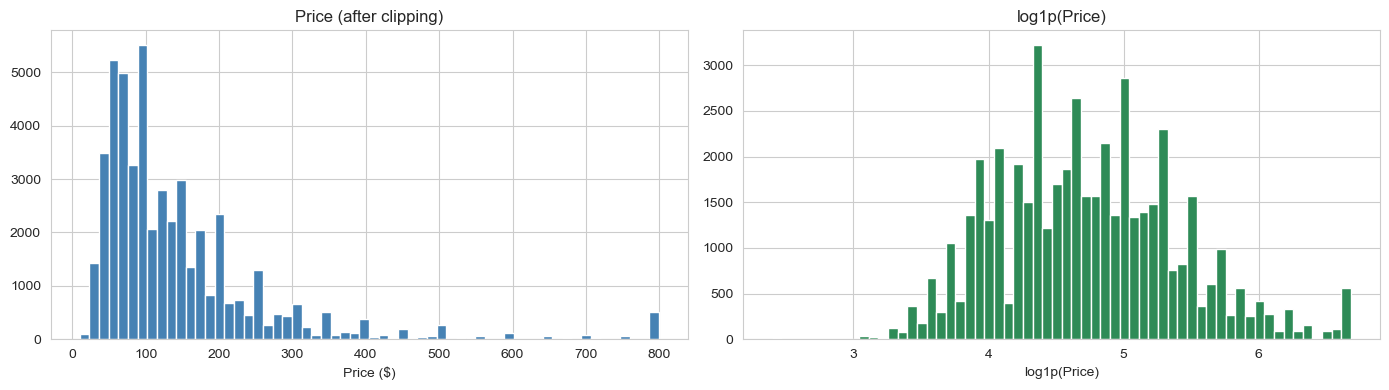

Skewness raw price: 2.777
Skewness log price: 0.367


In [20]:
df_clean["price_log"] = np.log1p(df_clean["price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean["price"].hist(bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Price (after clipping)")
axes[0].set_xlabel("Price ($)")

df_clean["price_log"].hist(bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(Price)")
axes[1].set_xlabel("log1p(Price)")

plt.tight_layout()
plt.show()

print("Skewness raw price:", df_clean["price"].skew().round(3))
print("Skewness log price:", df_clean["price_log"].skew().round(3))

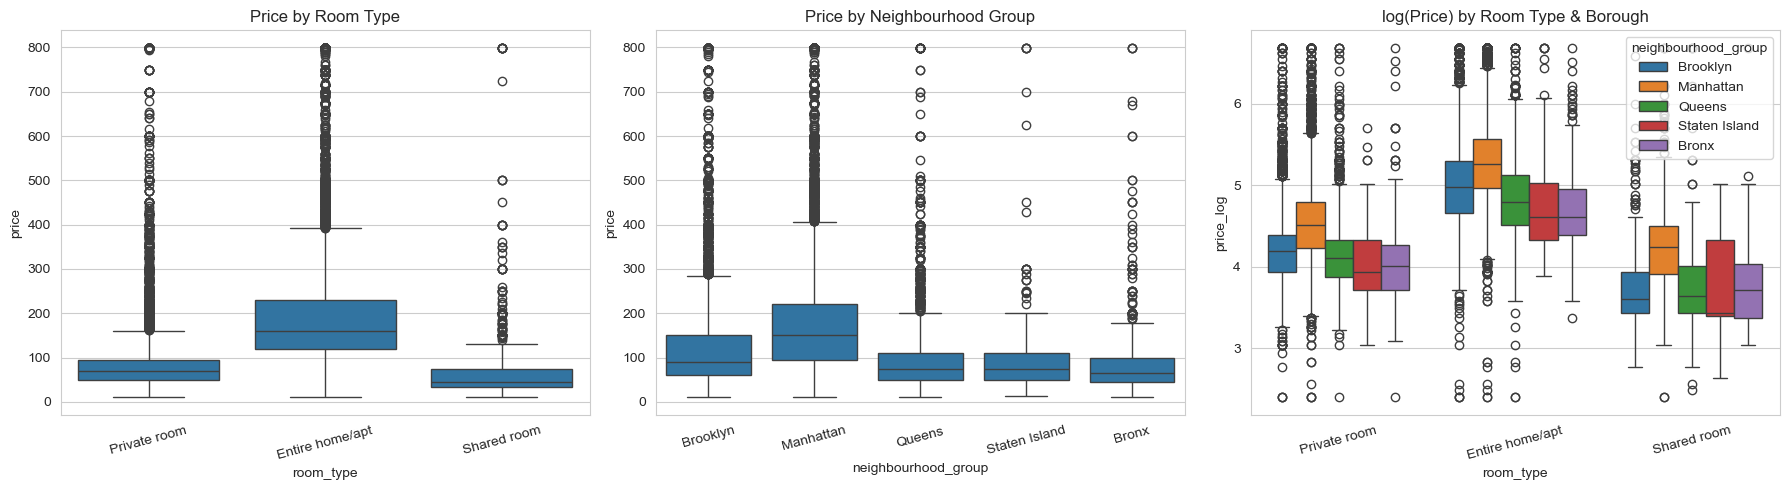

Median price by room_type:
room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64

Median price by neighbourhood_group:
neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_clean, x="room_type", y="price", ax=axes[0])
axes[0].set_title("Price by Room Type")
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_clean, x="neighbourhood_group", y="price", ax=axes[1])
axes[1].set_title("Price by Neighbourhood Group")
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_clean, x="room_type", y="price_log", hue="neighbourhood_group", ax=axes[2])
axes[2].set_title("log(Price) by Room Type & Borough")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("Median price by room_type:")
print(df_clean.groupby("room_type")["price"].median().sort_values(ascending=False))

print("\nMedian price by neighbourhood_group:")
print(df_clean.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False))

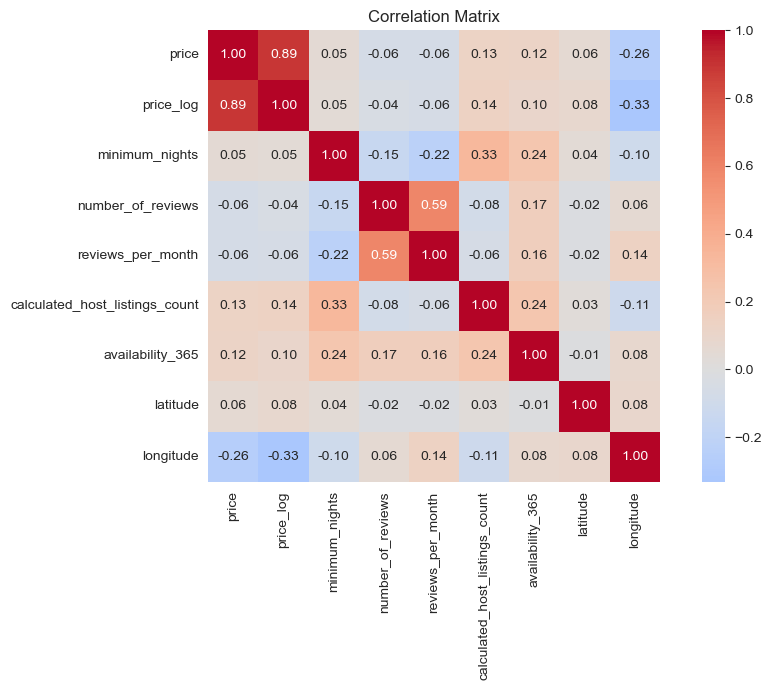

In [22]:
num_cols = ["price", "price_log", "minimum_nights", "number_of_reviews",
            "reviews_per_month", "calculated_host_listings_count",
            "availability_365", "latitude", "longitude"]

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

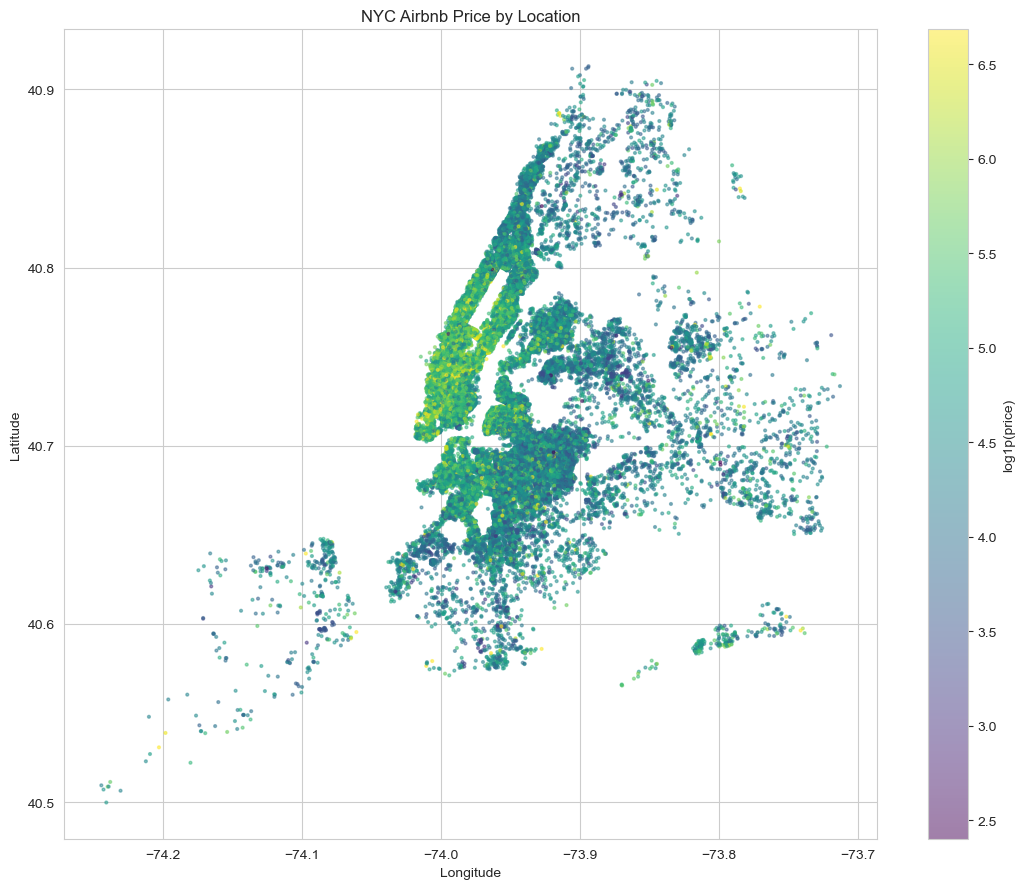

In [23]:
plt.figure(figsize=(11, 9))
sc = plt.scatter(df_clean["longitude"], df_clean["latitude"],
                 c=df_clean["price_log"], cmap="viridis",
                 s=4, alpha=0.5)
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NYC Airbnb Price by Location")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

# Features
feature_cols = [
    "neighbourhood_group", "neighbourhood", "latitude", "longitude",
    "room_type", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count",
    "availability_365"
]

X = df_clean[feature_cols]
y = df_clean["price_log"]

# Column groups
num_cols = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
            "reviews_per_month", "calculated_host_listings_count", "availability_365"]
cat_cols = ["neighbourhood_group", "room_type"]
high_card_col = ["neighbourhood"]  # we'll handle separately

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("High-cardinality column:", high_card_col)

X shape: (48884, 10)
y shape: (48884,)

Numeric columns: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical columns: ['neighbourhood_group', 'room_type']
High-cardinality column: ['neighbourhood']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (39107, 10)
Test size: (9777, 10)


In [27]:
import sys
!{sys.executable} -m pip install category_encoders

  Using cached category_encoders-2.11.1-py3-none-any.whl.metadata (8.4 kB)
Using cached category_encoders-2.11.1-py3-none-any.whl (107 kB)


In [28]:
from category_encoders import TargetEncoder
print("OK")

OK


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_enc", TargetEncoder(smoothing=10.0))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
    ("high", high_card_pipe, high_card_col)
])

print("Preprocessor built successfully")
print(preprocessor)

Preprocessor built successfully
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'room_type']),
      

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print(f"{len(models)} models ready to compare")
for name in models:
    print(f"  - {name}")


5 models ready to compare
  - Linear Regression
  - Ridge
  - Decision Tree
  - Random Forest
  - Gradient Boosting


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import time

results = []
trained_pipelines = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    t0 = time.time()

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    # Predictions in log-space
    y_train_pred_log = pipe.predict(X_train)
    y_test_pred_log  = pipe.predict(X_test)

    # Convert back to $ using expm1
    y_train_pred = np.expm1(y_train_pred_log)
    y_test_pred  = np.expm1(y_test_pred_log)
    y_train_real = np.expm1(y_train)
    y_test_real  = np.expm1(y_test)

    # Metrics
    train_r2  = r2_score(y_train, y_train_pred_log)
    test_r2   = r2_score(y_test, y_test_pred_log)
    test_mae  = mean_absolute_error(y_test_real, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_real, y_test_pred))

    elapsed = time.time() - t0

    results.append({
        "Model": name,
        "Train R²": round(train_r2, 4),
        "Test R²": round(test_r2, 4),
        "Test MAE ($)": round(test_mae, 2),
        "Test RMSE ($)": round(test_rmse, 2),
        "Time (s)": round(elapsed, 1),
    })
    trained_pipelines[name] = pipe
    print(f"   ✅ done in {elapsed:.1f}s | Test R² = {test_r2:.4f} | MAE = ${test_mae:.2f}")

results_df = pd.DataFrame(results).sort_values("Test R²", ascending=False)
results_df


🔄 Training Linear Regression...
   ✅ done in 0.1s | Test R² = 0.5524 | MAE = $52.36

🔄 Training Ridge...
   ✅ done in 0.1s | Test R² = 0.5524 | MAE = $52.36

🔄 Training Decision Tree...
   ✅ done in 0.2s | Test R² = 0.5670 | MAE = $50.92

🔄 Training Random Forest...
   ✅ done in 2.3s | Test R² = 0.6098 | MAE = $48.41

🔄 Training Gradient Boosting...
   ✅ done in 3.6s | Test R² = 0.5945 | MAE = $50.18


,Model,Train R²,Test R²,Test MAE ($),Test RMSE ($),Time (s)
3,Random Forest,0.9479,0.6098,48.41,93.16,2.3
4,Gradient Boosting,0.6184,0.5945,50.18,97.89,3.6
2,Decision Tree,0.6652,0.5670,50.92,98.28,0.2
0,Linear Regression,0.5739,0.5524,52.36,100.93,0.1
1,Ridge,0.5739,0.5524,52.36,100.93,0.1


In [32]:
from sklearn.model_selection import RandomizedSearchCV

# --- Random Forest search space ---
rf_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20, 25, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_jobs=-1, random_state=42))
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("🚀 Tuning Random Forest (15 random combos x 3-fold CV = 45 fits)...")
rf_search.fit(X_train, y_train)

print("\n✅ Best params:")
for k, v in rf_search.best_params_.items():
    print(f"   {k} = {v}")
print(f"\nBest CV R²: {rf_search.best_score_:.4f}")

🚀 Tuning Random Forest (15 random combos x 3-fold CV = 45 fits)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Best params:
   model__n_estimators = 200
   model__min_samples_split = 5
   model__min_samples_leaf = 2
   model__max_features = log2
   model__max_depth = 25

Best CV R²: 0.6326


In [33]:
gb_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0],
}

gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=gb_param_dist,
    n_iter=15,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("🚀 Tuning Gradient Boosting...")
gb_search.fit(X_train, y_train)

print("\n✅ Best params:")
for k, v in gb_search.best_params_.items():
    print(f"   {k} = {v}")
print(f"\nBest CV R²: {gb_search.best_score_:.4f}")

🚀 Tuning Gradient Boosting...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Best params:
   model__subsample = 1.0
   model__n_estimators = 300
   model__min_samples_split = 10
   model__min_samples_leaf = 4
   model__max_depth = 5
   model__learning_rate = 0.1

Best CV R²: 0.6311


In [34]:
def evaluate_model(name, search):
    pipe = search.best_estimator_

    y_train_pred_log = pipe.predict(X_train)
    y_test_pred_log  = pipe.predict(X_test)

    y_test_pred  = np.expm1(y_test_pred_log)
    y_test_real  = np.expm1(y_test)

    return {
        "Model": name,
        "Train R²": round(r2_score(y_train, y_train_pred_log), 4),
        "Test R²":  round(r2_score(y_test,  y_test_pred_log),  4),
        "Test MAE ($)":  round(mean_absolute_error(y_test_real, y_test_pred), 2),
        "Test RMSE ($)": round(np.sqrt(mean_squared_error(y_test_real, y_test_pred)), 2),
    }

tuned_results = pd.DataFrame([
    evaluate_model("Tuned Random Forest", rf_search),
    evaluate_model("Tuned Gradient Boosting", gb_search),
]).sort_values("Test R²", ascending=False)

tuned_results

,Model,Train R²,Test R²,Test MAE ($),Test RMSE ($)
0,Tuned Random Forest,0.8547,0.6246,47.56,93.37
1,Tuned Gradient Boosting,0.6919,0.6192,48.15,93.76


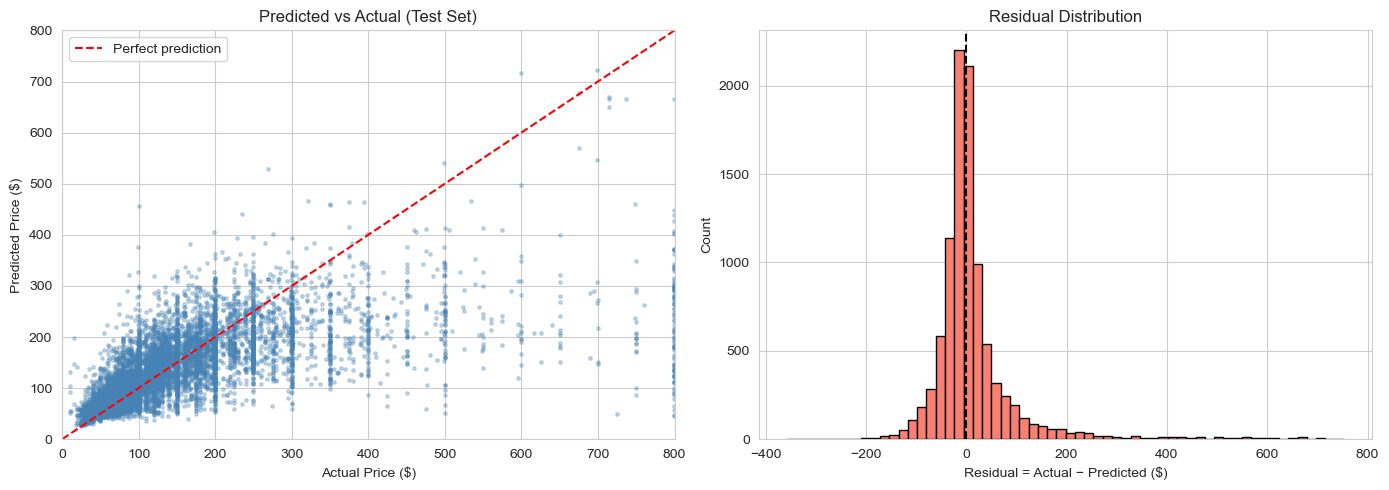

Mean residual: $ 14.41
Std of residuals: $ 92.25


In [35]:
best_pipe = rf_search.best_estimator_

y_test_pred_log = best_pipe.predict(X_test)
y_test_pred     = np.expm1(y_test_pred_log)
y_test_real     = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test_real, y_test_pred, alpha=0.3, s=6, color="steelblue")
lims = [0, 800]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Predicted vs Actual (Test Set)")
axes[0].legend()

# Residuals
residuals = y_test_real - y_test_pred
axes[1].hist(residuals, bins=60, color="salmon", edgecolor="black")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Residual = Actual − Predicted ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print("Mean residual: $", round(residuals.mean(), 2))
print("Std of residuals: $", round(residuals.std(), 2))

/var/folders/gd/f623hdfj18525ljz8j2n7x6c0000gn/T/ipykernel_42295/2796903588.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="Importance", y="Feature", palette="viridis")


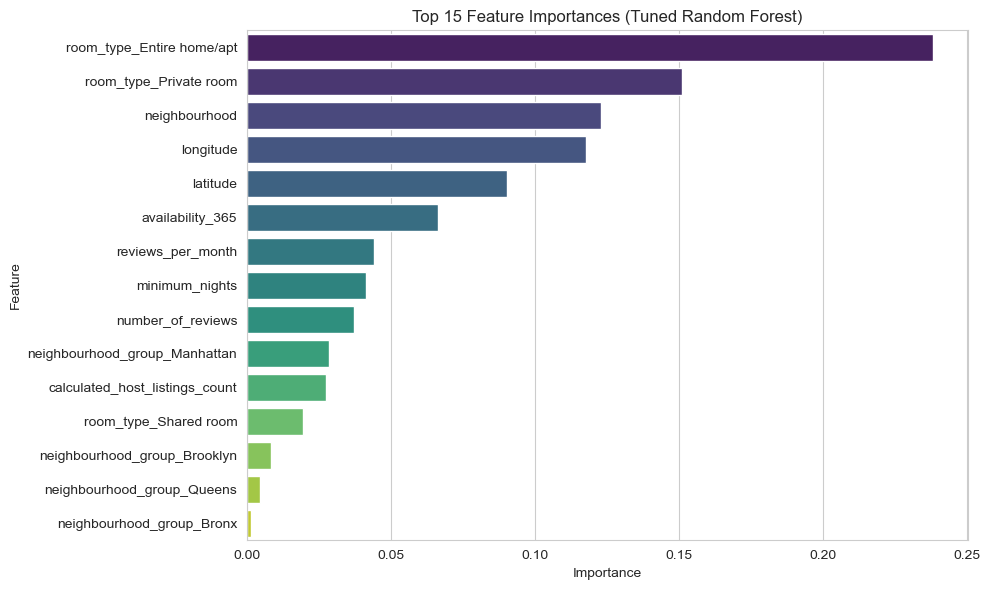

,Feature,Importance
12,room_type_Entire home/apt,0.238431
13,room_type_Private room,0.151146
15,neighbourhood,0.122994
1,longitude,0.117908
0,latitude,0.090399
6,availability_365,0.066462
4,reviews_per_month,0.044272
2,minimum_nights,0.041212
3,number_of_reviews,0.037198
9,neighbourhood_group_Manhattan,0.028554


In [36]:
# Extract feature names after preprocessing
ohe = best_pipe.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_names + high_card_col

importances = best_pipe.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Feature Importances (Tuned Random Forest)")
plt.tight_layout()
plt.show()

imp_df

In [38]:
import joblib
import gzip
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

model_path = "../models/airbnb_price_pipeline.pkl.gz"

# Save with compression (compress level 3 = good balance of size vs speed)
with gzip.open(model_path, "wb", compresslevel=3) as f:
    joblib.dump(best_pipe, f)

# Quick sanity check: reload and predict
with gzip.open(model_path, "rb") as f:
    loaded_pipe = joblib.load(f)

sample_pred_log = loaded_pipe.predict(X_test.iloc[:5])
sample_pred = np.expm1(sample_pred_log)

print(f"✅ Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")
print("\nSanity check — first 5 test predictions ($):")
print(sample_pred.round(2))
print("\nActual prices ($):")
print(np.expm1(y_test.iloc[:5]).round(2).values)

✅ Model saved to: ../models/airbnb_price_pipeline.pkl.gz
File size: 70.70 MB

Sanity check — first 5 test predictions ($):
[100.55  89.46 104.06  57.96  97.99]

Actual prices ($):
[99. 90. 80. 60. 90.]


In [39]:
import os
old_path = "../models/airbnb_price_pipeline.pkl"
if os.path.exists(old_path):
    os.remove(old_path)
    print(f"🗑️  Deleted {old_path}")
else:
    print("Old file not found (already clean)")

🗑️  Deleted ../models/airbnb_price_pipeline.pkl
